# 04 - Smell Detection (BERT + incompleteness rules)

- **`ambiguity`, `weak_verb`** - a single **BERT multi-label classifier** (2 outputs).
- **`incompleteness`** - a small, precision-oriented **regex** for explicit placeholder markers (`TBD`, `TODO`, `<x>`, ellipses, `[INSERT_]`, …).

## 1. Imports and setup

In [1]:
import random
import re
from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    confusion_matrix, f1_score,
    precision_score, recall_score, hamming_loss,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "promise_final.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
set_seed(RANDOM_STATE)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

df = pd.read_csv(DATA_PATH)
SMELL_LABELS = ["ambiguity", "weak_verb"]
print(f"Data: {len(df)} requirements")
print(f"\nSmell distribution:")
for s in SMELL_LABELS + ["incompleteness"]:
    n = int(df[s].sum())
    print(f"  {s:16s}: {n} ({n/len(df)*100:.1f}%)")

def save_fig(name):
    for ext in ["pdf", "png"]:
        plt.savefig(FIGURES_DIR / f"{name}.{ext}", dpi=300, bbox_inches='tight')

Device: mps
Data: 3677 requirements

Smell distribution:
  ambiguity       : 707 (19.2%)
  weak_verb       : 595 (16.2%)
  incompleteness  : 25 (0.7%)


## 2. Train/val/test split

In [2]:
X = df["text"].values
Y = df[SMELL_LABELS].values.astype(np.float32)
inc = df["incompleteness"].values.astype(int)
groups = df["project_id"].values

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(X, Y, groups=groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
Y_trainval, Y_test = Y[trainval_idx], Y[test_idx]
inc_test = inc[test_idx]
groups_trainval = groups[trainval_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss_val.split(X_trainval, Y_trainval, groups=groups_trainval))

X_train, X_val = X_trainval[train_idx], X_trainval[val_idx]
Y_train, Y_val = Y_trainval[train_idx], Y_trainval[val_idx]

print(f"Train: {len(X_train)} reqs from {pd.Series(groups_trainval[train_idx]).nunique()} projects")
print(f"Val:   {len(X_val)} reqs from {pd.Series(groups_trainval[val_idx]).nunique()} projects")
print(f"Test:  {len(X_test)} reqs from {pd.Series(groups[test_idx]).nunique()} projects")

print(f"\nSmell prevalence per split:")
for i, s in enumerate(SMELL_LABELS):
    n_tr = int(Y_train[:, i].sum())
    n_va = int(Y_val[:, i].sum())
    n_te = int(Y_test[:, i].sum())
    print(f"  {s:12s}: train {n_tr}/{len(Y_train)} ({n_tr/len(Y_train)*100:.1f}%) | val {n_va}/{len(Y_val)} | test {n_te}/{len(Y_test)} ({n_te/len(Y_test)*100:.1f}%)")
print(f"  {'incompleteness':12s}: train (n/a, rule-based) | test {int(inc_test.sum())}/{len(inc_test)} ({inc_test.mean()*100:.1f}%)")

Train: 2263 reqs from 59 projects
Val:   331 reqs from 11 projects
Test:  1083 reqs from 18 projects

Smell prevalence per split:
  ambiguity   : train 479/2263 (21.2%) | val 80/331 | test 148/1083 (13.7%)
  weak_verb   : train 462/2263 (20.4%) | val 27/331 | test 106/1083 (9.8%)
  incompleteness: train (n/a, rule-based) | test 8/1083 (0.7%)


## 3. Incompleteness rule detector

In [3]:
INC_PATTERN = re.compile(
    r"<[a-zA-Z][^>]*>"
    r"|\bTBD\b|\bTODO\b|\bFIXME\b|\bXXX\b"
    r"|\bN/?A\b"
    r"|\[(?:INSERT|TBD|TODO|FIXME)[^\]]*\]"
    r"|\.{3,}",
    re.IGNORECASE
)


def rule_incompleteness(text):
    """Lexical placeholder detection only (precision-oriented; P~1.0, low recall)."""
    return int(bool(INC_PATTERN.search(text)))


inc_pred_rules = np.array([rule_incompleteness(t) for t in X_test])

p_inc = precision_score(inc_test, inc_pred_rules, zero_division=0)
r_inc = recall_score(inc_test, inc_pred_rules, zero_division=0)
f_inc = f1_score(inc_test, inc_pred_rules, zero_division=0)
print(f"Incompleteness rule detector (test):  P={p_inc:.3f}, R={r_inc:.3f}, F1={f_inc:.3f}")
print(f"  positives in test: {int(inc_test.sum())} / {len(inc_test)}")

Incompleteness rule detector (test):  P=1.000, R=0.125, F1=0.222
  positives in test: 8 / 1083


## 4. Tokenizer and multi-label dataset

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class MultiLabelDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx],
        }

train_ds = MultiLabelDataset(X_train, Y_train, tokenizer)
val_ds = MultiLabelDataset(X_val, Y_val, tokenizer)
test_ds = MultiLabelDataset(X_test, Y_test, tokenizer)
print(f"Datasets ready. Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Datasets ready. Train: 2263, Val: 331, Test: 1083


## 5. BERT multi-label training

In [5]:
def compute_metrics_multilabel(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs > 0.5).astype(int)
    labels = labels.astype(int)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_micro": f1_score(labels, preds, average="micro", zero_division=0),
        "hamming_loss": hamming_loss(labels, preds),
    }

set_seed(RANDOM_STATE)
model_smell = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(SMELL_LABELS),
    problem_type="multi_label_classification",
)

NUM_EPOCHS = 5
BATCH_SIZE = 16
steps_per_epoch = int(np.ceil(len(train_ds) / BATCH_SIZE))
warmup_steps = int(0.1 * steps_per_epoch * NUM_EPOCHS)

tmp_smell = MODELS_DIR / "bert_smell_tmp"
training_args = TrainingArguments(
    output_dir=str(tmp_smell),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    report_to="none",
    seed=RANDOM_STATE,
    fp16=False,
    bf16=False,
    dataloader_pin_memory=False,
)

trainer_smell = Trainer(
    model=model_smell,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics_multilabel,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_smell.train()
print("Smell BERT training completed.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.419703,0.289771,0.450000,0.385714,0.129909,4.909000,67.427000,2.241000
2,0.191257,0.196663,0.827935,0.788732,0.067976,6.373700,51.932000,1.726000
3,0.086612,0.183653,0.862807,0.840580,0.049849,6.434500,51.441000,1.710000
4,0.051646,0.186056,0.870952,0.844660,0.048338,4.915900,67.332000,2.238000
5,0.038682,0.183524,0.883080,0.854369,0.045317,9.910600,33.399000,1.110000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Smell BERT training completed.


## 6. BERT test evaluation

In [6]:
pred_output = trainer_smell.predict(test_ds)
Y_pred_logits = pred_output.predictions
Y_pred_probs = torch.sigmoid(torch.tensor(Y_pred_logits)).numpy()
Y_pred_bert = (Y_pred_probs > 0.5).astype(int)

print("BERT-only test set predictions:")
for i, s in enumerate(SMELL_LABELS):
    p = precision_score(Y_test[:, i], Y_pred_bert[:, i], zero_division=0)
    r = recall_score(Y_test[:, i], Y_pred_bert[:, i], zero_division=0)
    f = f1_score(Y_test[:, i], Y_pred_bert[:, i], zero_division=0)
    print(f"  {s:12s}: P={p:.3f}, R={r:.3f}, F1={f:.3f}")

f1_macro_bert = f1_score(Y_test, Y_pred_bert, average="macro", zero_division=0)
f1_micro_bert = f1_score(Y_test, Y_pred_bert, average="micro", zero_division=0)
hl_bert = hamming_loss(Y_test.astype(int), Y_pred_bert)

print(f"\n  Macro F1:     {f1_macro_bert:.4f}")
print(f"  Micro F1:     {f1_micro_bert:.4f}")
print(f"  Hamming loss: {hl_bert:.4f}")

BERT-only test set predictions:
  ambiguity   : P=0.895, R=0.865, F1=0.880
  weak_verb   : P=0.933, R=0.925, F1=0.929

  Macro F1:     0.9043
  Micro F1:     0.9004
  Hamming loss: 0.0231


## 7. BERT per-label performance

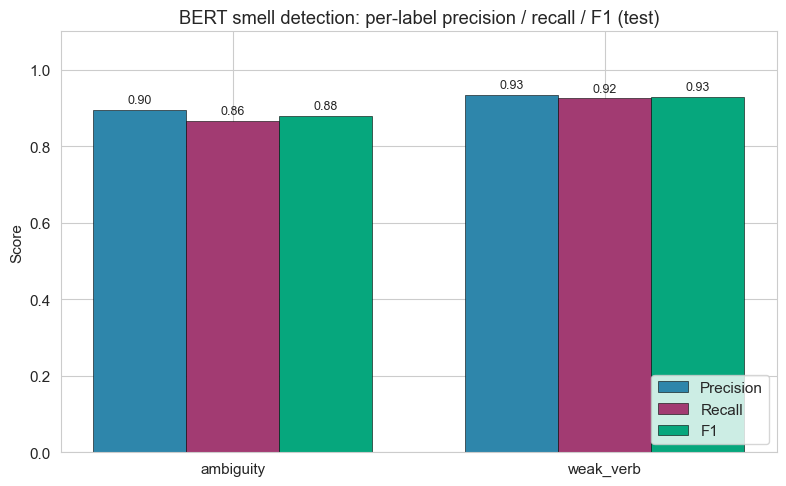

In [11]:
metrics_bert = {}
for i, s in enumerate(SMELL_LABELS):
    metrics_bert[s] = {
        "precision": precision_score(Y_test[:, i], Y_pred_bert[:, i], zero_division=0),
        "recall":    recall_score(Y_test[:, i], Y_pred_bert[:, i], zero_division=0),
        "f1":        f1_score(Y_test[:, i], Y_pred_bert[:, i], zero_division=0),
    }

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(SMELL_LABELS))
width = 0.25
colors = {"precision": "#2E86AB", "recall": "#A23B72", "f1": "#06A77D"}
for j, metric in enumerate(["precision", "recall", "f1"]):
    vals = [metrics_bert[s][metric] for s in SMELL_LABELS]
    bars = ax.bar(x + (j - 1) * width, vals, width, label=metric.capitalize(),
                  color=colors[metric], edgecolor="black", linewidth=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.2f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(SMELL_LABELS)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("BERT smell detection: per-label precision / recall / F1 (test)")
ax.legend(loc="lower right")
plt.tight_layout()
save_fig("fig_smell_01_bert_per_label")
plt.show()

## 8. Confusion matrices (BERT)

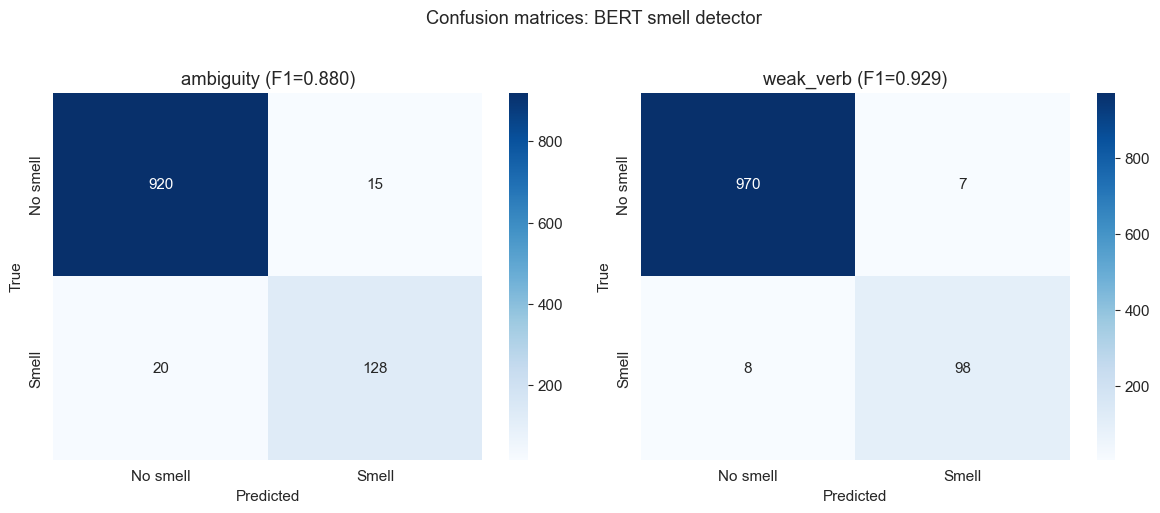

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, s in enumerate(SMELL_LABELS):
    cm = confusion_matrix(Y_test[:, i].astype(int), Y_pred_bert[:, i])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No smell", "Smell"],
                yticklabels=["No smell", "Smell"],
                ax=axes[i])
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")
    f1 = f1_score(Y_test[:, i], Y_pred_bert[:, i], zero_division=0)
    axes[i].set_title(f"{s} (F1={f1:.3f})")

plt.suptitle("Confusion matrices: BERT smell detector", y=1.02)
plt.tight_layout()
save_fig("fig_smell_02_confusion_matrices")
plt.show()

## 9. Incompleteness: detailed results

In [9]:
print(f"Incompleteness rule-based detection on test:")
print(f"  Positives in test: {int(inc_test.sum())} / {len(inc_test)} ({inc_test.mean()*100:.2f}%)")
print(f"  Precision: {precision_score(inc_test, inc_pred_rules, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(inc_test, inc_pred_rules, zero_division=0):.4f}")
print(f"  F1:        {f1_score(inc_test, inc_pred_rules, zero_division=0):.4f}")

# Examples
print(f"\nFalse negatives:")
fn = (inc_test == 1) & (inc_pred_rules == 0)
for idx in np.where(fn)[0][:5]:
    print(f"  - {X_test[idx][:160]}")

print(f"\nFalse positives:")
fp = (inc_test == 0) & (inc_pred_rules == 1)
for idx in np.where(fp)[0][:5]:
    print(f"  - {X_test[idx][:160]}")

Incompleteness rule-based detection on test:
  Positives in test: 8 / 1083 (0.74%)
  Precision: 1.0000
  Recall:    0.1250
  F1:        0.2222

False negatives:
  - Interfaces to submit evidence to the VCD system have to be defined along with common semantics in order to allow issuing bodies to further specify evidence with
  - It has to be defined which method and concept should be applied if there are missing attestations.
  - Hence, adoption and approval procedures have to be defined and enacted in order to install the pre-VCD mapping and pre-VCD mapping tool as an official mapping m
  - By which technical means will the mapping be provided? The technical means to provide the mapping service has to be defined in dependence on the choice of the p
  - Which entity will host the mapping facility? In dependence of the choice of infrastructures (centralised – decentralized) and the organisation that governs the 

False positives:


## 10. Save model and metrics

In [12]:
smell_dir = MODELS_DIR / "bert_smell"
trainer_smell.save_model(str(smell_dir))
tokenizer.save_pretrained(str(smell_dir))
shutil.rmtree(tmp_smell, ignore_errors=True)
print(f"BERT smell model saved: {smell_dir}")

bert_per_label = {
    s: {
        "precision": float(precision_score(Y_test[:, i], Y_pred_bert[:, i], zero_division=0)),
        "recall":    float(recall_score(Y_test[:, i], Y_pred_bert[:, i], zero_division=0)),
        "f1":        float(f1_score(Y_test[:, i], Y_pred_bert[:, i], zero_division=0)),
    }
    for i, s in enumerate(SMELL_LABELS)
}

metrics_smell = {
    "model": "bert-base-uncased (multi-label: ambiguity + weak_verb)",
    "smell_labels": SMELL_LABELS,
    "n_train": int(len(X_train)),
    "n_val": int(len(X_val)),
    "n_test": int(len(X_test)),
    "bert": {
        "per_label": bert_per_label,
        "f1_macro": float(f1_macro_bert),
        "f1_micro": float(f1_micro_bert),
        "hamming_loss": float(hl_bert),
    },
    "incompleteness": {
        "approach": "rule-based only (regex; ML not used — only 25 positive examples)",
        "n_positive_test": int(inc_test.sum()),
        "n_total_test": int(len(inc_test)),
        "test_precision": float(precision_score(inc_test, inc_pred_rules, zero_division=0)),
        "test_recall": float(recall_score(inc_test, inc_pred_rules, zero_division=0)),
        "test_f1": float(f1_score(inc_test, inc_pred_rules, zero_division=0)),
    },
}

metrics_path = MODELS_DIR / "smell_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics_smell, f, indent=2)
print(f"Metrics saved: {metrics_path}")

print(f"\nFinal Smell Detection Summary:")
print(f"BERT (ambiguity + weak_verb) — F1 macro: {f1_macro_bert:.4f}")
for s in SMELL_LABELS:
    print(f"    {s:12s}: F1 = {bert_per_label[s]['f1']:.4f}")
print(f"Incompleteness (rules only): F1 = {metrics_smell['incompleteness']['test_f1']:.4f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT smell model saved: /Users/luciano/Developer/requirements-analyzer/models/bert_smell
Metrics saved: /Users/luciano/Developer/requirements-analyzer/models/smell_metrics.json

Final Smell Detection Summary:
BERT (ambiguity + weak_verb) — F1 macro: 0.9043
    ambiguity   : F1 = 0.8797
    weak_verb   : F1 = 0.9289
Incompleteness (rules only): F1 = 0.2222
